# Reconstruction scorer

This notebook is used to run a reconstruction in several configurations, showing its score in the reconstruction of a given function

## WARNING! THIS IS A WORK IN PROGRESS!

In [74]:
import sys
import pprint
import seaborn as sb
import numpy   as np
import pandas  as pd
import random  as rnd

from CoRe.reconstruction_tools.GaussianProcess import GPCalculator
from CoRe.utils.diagnostics import Scorer

from copy    import deepcopy
from time    import time
from tqdm    import tqdm
from itertools import product

from getdist import plots,MCSamples

#Plotting
import matplotlib
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt

from matplotlib import rc


rc('text', usetex=True)
rc('font', family='serif')
matplotlib.rcParams.update({'font.size': 18})

red    = '#8e001c'
yellow = '#ffb302'

sidelegend = {'bbox_to_anchor': (1.04,0.5), 
              'loc': "center left",
              'frameon': False}
bottomlegend = {'bbox_to_anchor': (0.35,-0.2), 
                'loc': "center left",
                'frameon': False,
                'ncols': 3}

# Some functions

In [2]:
def get_theory(params):

    from numpy.polynomial import Polynomial
    
    p = Polynomial(params)
    # Compute derivatives and integral using NumPy's built-in methods
    p_deriv1 = p.deriv(m=1)   # First derivative
    p_deriv2 = p.deriv(m=2)   # Second derivative
    p_integ  = p.integ(m=1)   # Antiderivative (integration constant C=0)
    results = {'f': lambda x: p(x),
               'd1': lambda x: p_deriv1(x),
               'd2': lambda x: p_deriv2(x),
               'int': lambda x: p_integ(x)}

    return results

def create_data(theory_model,Ndata,xmin,xmax,err_fac,seed=None):

    dataset = pd.DataFrame({'x': np.random.uniform(xmin,xmax,Ndata)})
    
    thvals           = theory_model['f'](dataset['x'])
    errors           = abs(thvals)*err_fac/100
    if seed != None:
        rng = np.random.default_rng(seed=seed)
        dataset['f'] = rng.normal(thvals,errors)
    else:
        dataset['f'] = np.random.normal(thvals,errors)
    dataset['f_err'] = errors
    
    covmat = pd.DataFrame(np.diag(errors*2),columns=['f_{}'+format(ind) for ind in range(len(dataset['x']))])
    covmat.index = covmat.columns

    return dataset,covmat

def get_GP(dataset,covmat,kernel,x_recon,method):

    gp = GPCalculator(dataset,covmat,kernel_type=kernel,chatty=False)

    means, joint_cov, lml, info = gp.reconstruct(x_recon,method=method)

    return means,joint_cov,lml

# Diagnostic tools

Once a reconstruction is complete, it is critical to quantify how well the GP model represents the underlying physics. The Scorer class implements frequentist statistical tests to measure the "tension" between the reconstruction and other references.

## Interpreting the Results
The `Scorer` returns metrics to help interpret the statistical "tension":

* **Reduced $\chi^2$ ($\chi^2_{\nu}$):** Ideally near **1.0**. A value $\gg 1$ suggests the model is a poor fit or the tension is high; a value $\ll 1$ suggests the uncertainties are over-estimated.
* **p-value:** The probability of obtaining a result at least as extreme as the one observed.

### Tension Scale
The `Scorer` provides color-coded reports based on the p-value:
* **$p > 0.05$ (Green):** Good consistency. No significant evidence of tension.
* **$0.01 < p < 0.05$ (Yellow):** Marginal consistency. Potential tension that warrants investigation.
* **$p < 0.01$ (Red):** Poor consistency. Significant tension exists.

In [3]:
Nrecon  = 10
xmin    = 0.1
xmax    = 1.9
x_recon = np.linspace(xmin,xmax,Nrecon)

Ndata   = 20
mindata = 0.
maxdata = 2.
error   = 5

fiducial = {'a0': 3,
            'a1': -1,
            'a2': 5,
            'a3': -0.1}

method = 'MAP'
kernel = 'RBF'

derivatives = ['f','d1']
if kernel != 'MATERN3/2':
    derivatives = derivatives+['d2','int']

x_label = r'$x$'
y_label = r'$f(x)$'

In [4]:
theory = get_theory(list(fiducial.values()))

dataset,covmat = create_data(theory,Ndata,mindata,maxdata,error)

means,joint_cov,lml = get_GP(dataset,covmat,kernel,x_recon,method)

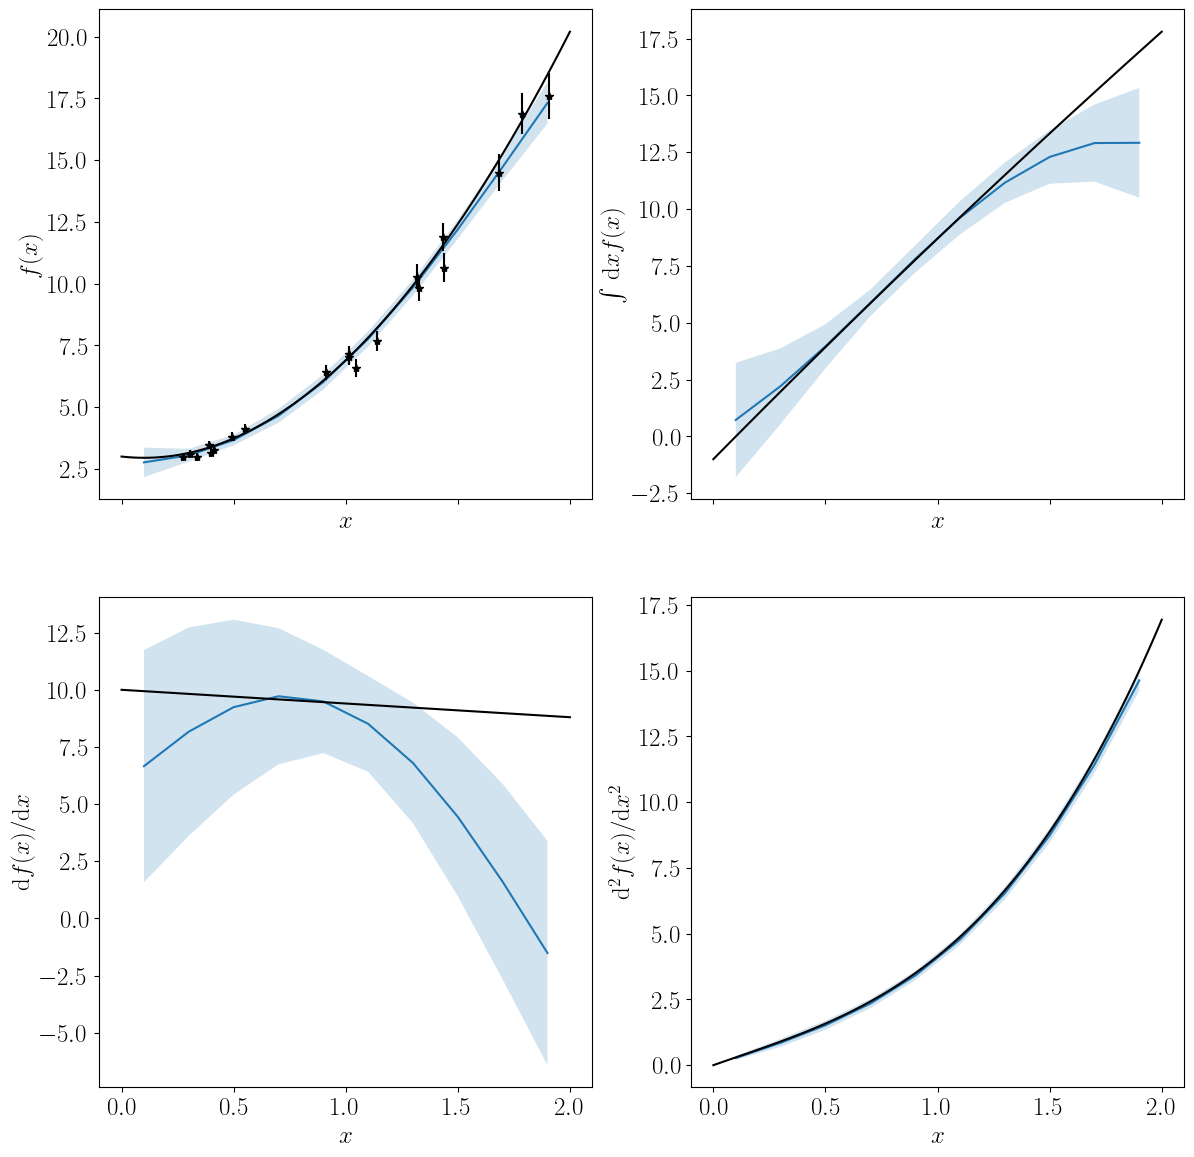

In [5]:
xplot = np.linspace(mindata,maxdata,100)
fig,axes = plt.subplots(nrows=2,ncols=2,sharey=False,sharex=True,figsize=(14,14))

for ind,deriv in enumerate(derivatives):
    if ind == 0:
        i = 0
        j = 0
        label = y_label
    elif ind == 1:
        i = 0
        j = 1
        label = r'$\int$ d'+x_label+''+y_label
    elif ind == 2:
        i = 1
        j = 0
        label = r'd'+y_label+'/d'+x_label
    elif ind == 3:
        i = 1
        j = 1
        label = r'd$^2$'+y_label+'/d'+x_label+r'$^2$'

    axes[i,j].fill_between(x_recon,means[deriv]+means[deriv+'_err'],means[deriv]-means[deriv+'_err'],alpha=0.2)
    axes[i,j].plot(means['x'],means[deriv])
    axes[i,j].plot(xplot,theory[deriv](xplot),color='black')
    if deriv == 'f':
        axes[i,j].errorbar(dataset['x'],dataset[deriv],yerr=dataset[deriv+'_err'],color='black',ls='',marker='*')
    axes[i,j].set_xlabel(x_label)
    axes[i,j].set_ylabel(label)

## Initialize Scorer

**Explain**

**ADD DISCUSSION OF EIGENVALUE SEPARATION**

In [6]:
from CoRe.utils.diagnostics import Scorer

scorer = Scorer(means,joint_cov,chatty=True)

In [7]:
GPdiagnostic = pd.DataFrame(columns=['total_chi2','red_chi2','p_value','dof'])

## 1. Scoring Against Theory (Accuracy)

When evaluating how well a reconstruction matches a theoretical curve $y_{th}(x)$, we must decide how to treat the relationship between different points in the reconstruction. The `Scorer` class provides two distinct statistical perspectives.

In [8]:
theory_df = pd.DataFrame({'x': x_recon}|{func: theory[func](x_recon) for func in derivatives})

### A. The Mahalanobis Distance (Joint Scoring)
The Mahalanobis distance measures the separation between the GP mean vector and the theory vector by accounting for the **full joint covariance matrix** ($\Sigma_{GP}$), including all off-diagonal correlations.

$$\chi^2_{joint} = (\vec{\mu}_{GP} - \vec{y}_{th})^T \mathbf{\Sigma}_{GP}^{-1} (\vec{\mu}_{GP} - \vec{y}_{th})$$

* **Global Shape Consistency:** It treats the entire curve as a single physical realization. Because GPs are smooth, a deviation at $x_1$ is physically linked to a deviation at $x_2$ via the kernel.
* **The "Rigidity" Factor:** This metric is highly sensitive to "shape" mismatches. If the theory curve has a slope or feature that the GP kernel cannot replicate, the Mahalanobis distance will increase significantly, even if the error bars are large.
* **When to use:** This is the most mathematically rigorous test for Gaussian Processes.

In [9]:
Mscore = scorer.score_against_theory(theory_df)
GPdiagnostic.loc['Mahalanobis'] = [Mscore[col] for col in GPdiagnostic.columns]


 SCORE REPORT: THEORY CONSISTENCY
Status (Full System): POOR (Significant Tension)
Full Total Chi2:      505893.48
Full Red.  Chi2:      12647.337
Full P-value:         0.0000
Full DOF:             40

Eigenmode Spectrum Breakdown (Sorted by Eigenvalue / Variance Descending):
Mode ID   | Eigenvalue (Var) | Chi2 Contrib  | Percentage | Status  
---------------------------------------------------------------------------
Mode 0    | 1.10e+02         | 0.43          |   0.0%     | ACTIVE
Mode 1    | 3.81e+01         | 3.25          |   0.0%     | ACTIVE
Mode 2    | 1.39e+01         | 4.00          |   0.0%     | ACTIVE
Mode 3    | 2.09e+00         | 0.44          |   0.0%     | ACTIVE
Mode 4    | 6.67e-01         | 1.48          |   0.0%     | ACTIVE
Mode 5    | 5.91e-01         | 0.03          |   0.0%     | ACTIVE
Mode 6    | 1.70e-02         | 9.71          |   0.0%     | ACTIVE
Mode 7    | 2.92e-04         | 1.00          |   0.0%     | ACTIVE
Mode 8    | 3.43e-06         | 14.18     

### B. Pointwise $\chi^2$ Scoring

The pointwise score ignores the correlations (off-diagonal elements) and compares the mean to the theory at each point using only the local variance $\sigma^2_i$.

$$\chi^2_{pointwise} = \sum_{i=1}^{N} \frac{(\mu_i - y_{th, i})^2}{\sigma_i^2}$$

* **Local Accuracy:** This answers the question: "At this specific redshift, how many sigma away is my reconstruction from the theory?"
* **Visual Intuition:** This matches our visual interpretation of plots. If the theory line stays within the $1\sigma$ shaded region, the pointwise $\chi^2$ per degree of freedom will be small.
* **The Risk of Over-optimism:** Because it ignores correlations, pointwise scoring often results in artificially high p-values. It "forgets" that the GP isn't allowed to fluctuate independently at every point, which can make a mediocre fit look statistically acceptable.

In [10]:
Dscore = scorer.score_pointwise(theory_df)
GPdiagnostic.loc['Pointwise'] = [Dscore[col] for col in GPdiagnostic.columns]


 SCORE REPORT: POINTWISE THEORY CONSISTENCY
Status (Full System): GOOD (Consistent)
Full Total Chi2:      23.00
Full Red.  Chi2:      0.575
Full P-value:         0.9857
Full DOF:             40

Pointwise Component Breakdown:
  - f    :     3.69 ( 16.0%)
  - d1   :     5.51 ( 23.9%)
  - d2   :    10.81 ( 47.0%)
  - int  :     3.00 ( 13.0%)



## 2. Scoring Against Data (Consistency)
This method compares the reconstruction against external data points that were not used in the training, or checks the self-consistency of the fit against a secondary probe.

### The Logic
Unlike the theory score, we must account for the uncertainties in **both** the reconstruction and the data. The total covariance is the sum of the two:

$$\chi^2_{data} = (\vec{y}_{data} - \vec{\mu}_{GP})^T \left[ \mathbf{\Sigma}_{GP} + \mathbf{\Sigma}_{data} \right]^{-1} (\vec{y}_{data} - \vec{\mu}_{GP})$$

The `Scorer` automatically handles the alignment of coordinates, extracting the GP's predicted values and covariance at the specific $x$-locations where the data points exist.

In [11]:
datasets = [{'type': 'f',
             'df': dataset,
             'cov': covmat}]

In [12]:
data_score = scorer.score_against_data(datasets)
GPdiagnostic.loc['Data'] = [data_score[col] for col in GPdiagnostic.columns]


 SCORE REPORT: EXTERNAL DATA VALIDATION
Status (Full System): GOOD (Consistent)
Full Total Chi2:      9.41
Full Red.  Chi2:      0.470
Full P-value:         0.9777
Full DOF:             20

Eigenmode Spectrum Breakdown (Sorted by Eigenvalue / Variance Descending):
Mode ID   | Eigenvalue (Var) | Chi2 Contrib  | Percentage | Status  
---------------------------------------------------------------------------
Mode 0    | 3.13e+00         | 0.16          |   1.7%     | ACTIVE
Mode 1    | 1.89e+00         | 0.00          |   0.0%     | ACTIVE
Mode 2    | 1.60e+00         | 3.29          |  34.9%     | ACTIVE
Mode 3    | 1.49e+00         | 0.26          |   2.8%     | ACTIVE
Mode 4    | 1.16e+00         | 1.24          |  13.2%     | ACTIVE
Mode 5    | 1.15e+00         | 0.17          |   1.8%     | ACTIVE
Mode 6    | 1.02e+00         | 0.08          |   0.9%     | ACTIVE
Mode 7    | 9.50e-01         | 0.58          |   6.1%     | ACTIVE
Mode 8    | 7.89e-01         | 0.67          |   7.2%

In [13]:
GPdiagnostic

,total_chi2,red_chi2,p_value,dof
Mahalanobis,505893.478427,12647.336961,0.000000,40.0
Pointwise,23.001706,0.575043,0.985672,40.0
Data,9.405938,0.470297,0.977711,20.0


## Eigenvalues truncation

**EXPLAIN TRUNCATION HERE**

In [14]:
GPdiagnostic = pd.DataFrame(columns=['total_chi2','red_chi2','p_value','dof',
                                     'truncated_chi2','truncated_red_chi2','truncated_p_value','truncated_dof'])

In [15]:
scorer = Scorer(means,joint_cov,chatty=True,eigen_trunc_factor=1.e-5)

In [16]:
Mscore = scorer.score_against_theory(theory_df)
GPdiagnostic.loc['Mahalanobis'] = [Mscore[col] for col in GPdiagnostic.columns]


 SCORE REPORT: THEORY CONSISTENCY
Status (Full System): POOR (Significant Tension)
Full Total Chi2:      505893.48
Full Red.  Chi2:      12647.337
Full P-value:         0.0000
Full DOF:             40
------------------------------------------------------------
Truncated Subspace Metrics (Cutoff Factor F = 1e-05):
Truncated Chi2:       19.32
Truncated Red. Chi2:  2.760
Truncated P-value:    0.0072
Truncated DOF:        7 (Dropped 33 noisy modes)

Eigenmode Spectrum Breakdown (Sorted by Eigenvalue / Variance Descending):
Mode ID   | Eigenvalue (Var) | Chi2 Contrib  | Percentage | Status  
---------------------------------------------------------------------------
Mode 0    | 1.10e+02         | 0.43          |   0.0%     | KEPT
Mode 1    | 3.81e+01         | 3.25          |   0.0%     | KEPT
Mode 2    | 1.39e+01         | 4.00          |   0.0%     | KEPT
Mode 3    | 2.09e+00         | 0.44          |   0.0%     | KEPT
Mode 4    | 6.67e-01         | 1.48          |   0.0%     | KEPT
Mod

In [17]:
data_score = scorer.score_against_data(datasets)
GPdiagnostic.loc['Data'] = [data_score[col] for col in GPdiagnostic.columns]


 SCORE REPORT: EXTERNAL DATA VALIDATION
Status (Full System): GOOD (Consistent)
Full Total Chi2:      9.41
Full Red.  Chi2:      0.470
Full P-value:         0.9777
Full DOF:             20
------------------------------------------------------------
Truncated Subspace Metrics (Cutoff Factor F = 1e-05):
Truncated Chi2:       9.41
Truncated Red. Chi2:  0.470
Truncated P-value:    0.9777
Truncated DOF:        20 (Dropped 0 noisy modes)

Eigenmode Spectrum Breakdown (Sorted by Eigenvalue / Variance Descending):
Mode ID   | Eigenvalue (Var) | Chi2 Contrib  | Percentage | Status  
---------------------------------------------------------------------------
Mode 0    | 3.13e+00         | 0.16          |   1.7%     | KEPT
Mode 1    | 1.89e+00         | 0.00          |   0.0%     | KEPT
Mode 2    | 1.60e+00         | 3.29          |  34.9%     | KEPT
Mode 3    | 1.49e+00         | 0.26          |   2.8%     | KEPT
Mode 4    | 1.16e+00         | 1.24          |  13.2%     | KEPT
Mode 5    | 1.15

In [18]:
GPdiagnostic

,total_chi2,red_chi2,p_value,dof,truncated_chi2,truncated_red_chi2,truncated_p_value,truncated_dof
Mahalanobis,505893.478427,12647.336961,0.000000,40.0,19.323159,2.760451,0.007233,7.0
Data,9.405938,0.470297,0.977711,20.0,9.405938,0.470297,0.977711,20.0


# Reconstruction grid

Here we use the scorer module to visualize the dependence of a Gaussian Process on different settings, running on a grid of several choice combinations.

**TO BE FINISHED!!!**

## Settings

In [44]:
data_range  = [0.,2.]
recon_range = [0.1,1.8]


free_settings = {'Nrecon': [5,7,10,12,15],
                 'order': [3,4,5],
                 'Ndata': [25,50,75,100],
                 'error': [1,5,10.],
                 'logtruncation': [-5,-8,-11],
                 'kernel': ['RBF'],
                 'method': ['MAP']}


prior_sampling = 1

## Run grid

In [45]:
import math
dfs = []

keys = free_settings.keys()

locind = 0
total  = math.prod(len(v) for v in free_settings.values())*prior_sampling
for values in product(*free_settings.values()):

    print('')
    loc_dict = dict(zip(keys, values))

    x_recon = np.linspace(recon_range[0],recon_range[1],loc_dict['Nrecon'])

    tini = time()
    df = pd.DataFrame(loc_dict,index=[0])
    
    #params = {'a{}'.format(ind): np.random.uniform(-5.,5) for ind in range(loc_dict['order']+1)}
    params = deepcopy(fiducial)
    theory = get_theory(list(params.values()))
    dataset,covmat = create_data(theory,loc_dict['Ndata'],data_range[0],data_range[1],loc_dict['error'],seed=42)
    
    means,joint_cov,lml = get_GP(dataset,covmat,loc_dict['kernel'],x_recon,loc_dict['method'])
    
    scorer = Scorer(means,joint_cov,chatty=False,eigen_trunc_factor=10**loc_dict['logtruncation'])
    
    theory_df = pd.DataFrame({'x': x_recon}|{func: theory[func](x_recon) for func in ['f','d1','d2','int']})
    res         = scorer.score_against_theory(theory_df)
    df['M-score']   = res['truncated_p_value']
    
    res = scorer.score_pointwise(theory_df)
    df['D-score'] = res['p_value']
    
    datasets = [{'type': 'f',
                 'df': dataset,
                 'cov': covmat}]
    res = scorer.score_against_data(datasets)
    df['Data score'] = res['truncated_p_value']
    
    dfs.append(df)
        
    print('Test {} of {} done in {:.2f} s'.format(locind+1,total,time()-tini))

    locind += 1

results = pd.concat(dfs,ignore_index=True)


Test 1 of 540 done in 12.05 s

Test 2 of 540 done in 9.46 s

Test 3 of 540 done in 8.06 s

Test 4 of 540 done in 8.55 s

Test 5 of 540 done in 12.35 s

Test 6 of 540 done in 8.99 s

Test 7 of 540 done in 8.88 s

Test 8 of 540 done in 8.55 s

Test 9 of 540 done in 8.21 s

Test 10 of 540 done in 15.04 s

Test 11 of 540 done in 12.06 s

Test 12 of 540 done in 9.84 s

Test 13 of 540 done in 9.79 s

Test 14 of 540 done in 9.89 s

Test 15 of 540 done in 10.12 s

Test 16 of 540 done in 10.09 s

Test 17 of 540 done in 8.54 s

Test 18 of 540 done in 8.37 s

Test 19 of 540 done in 18.91 s

Test 20 of 540 done in 8.49 s

Test 21 of 540 done in 8.73 s

Test 22 of 540 done in 10.13 s

Test 23 of 540 done in 9.21 s

Test 24 of 540 done in 10.09 s

Test 25 of 540 done in 12.98 s

Test 26 of 540 done in 9.17 s

Test 27 of 540 done in 9.03 s

Test 28 of 540 done in 13.47 s

Test 29 of 540 done in 7.98 s

Test 30 of 540 done in 8.67 s

Test 31 of 540 done in 9.15 s

Test 32 of 540 done in 10.35 s

Test

In [46]:
results

,Nrecon,order,Ndata,error,logtruncation,kernel,method,M-score,D-score,Data score
0,5,3,25,1.0,-5,RBF,MAP,0.005221,0.999414,0.000008
1,5,3,25,1.0,-8,RBF,MAP,0.006741,0.998572,0.000000
2,5,3,25,1.0,-11,RBF,MAP,0.000025,0.989997,0.000000
3,5,3,25,5.0,-5,RBF,MAP,0.011632,0.979032,0.087668
4,5,3,25,5.0,-8,RBF,MAP,0.038158,0.999812,0.705537
...,...,...,...,...,...,...,...,...,...,...
535,15,5,100,5.0,-8,RBF,MAP,0.012502,1.000000,1.000000
536,15,5,100,5.0,-11,RBF,MAP,0.000006,1.000000,0.999645
537,15,5,100,10.0,-5,RBF,MAP,0.010927,1.000000,1.000000
538,15,5,100,10.0,-8,RBF,MAP,0.008152,1.000000,1.000000


## Plotting resultd

In [63]:
parameters = ['Nrecon','Ndata','error','logtruncation']

### MAP results

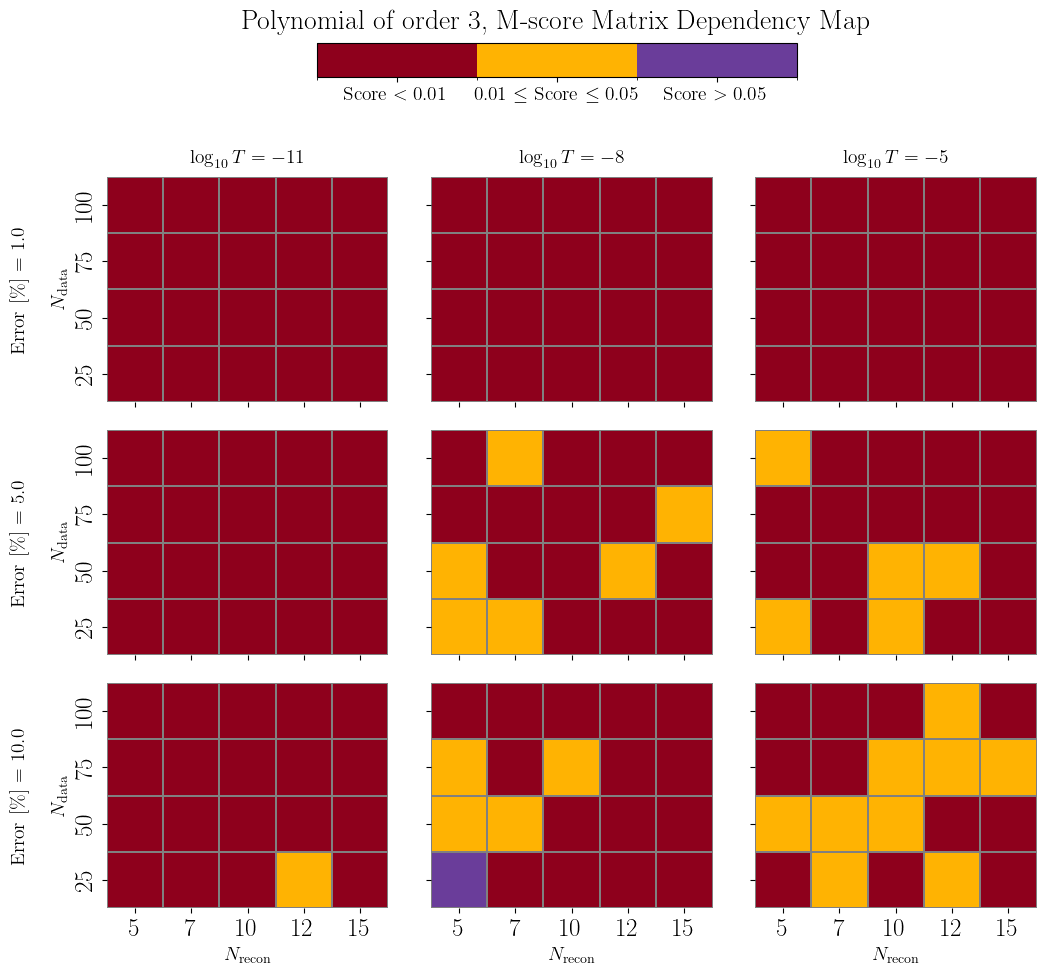

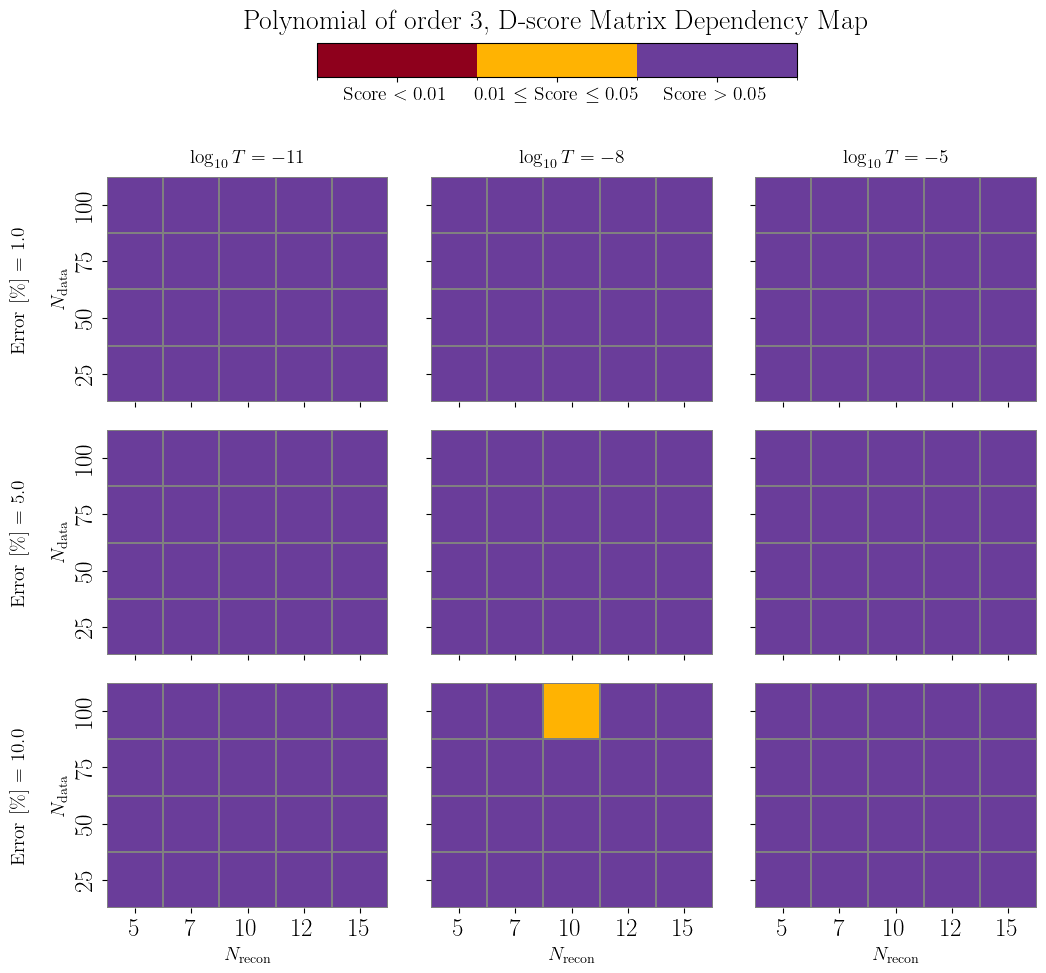

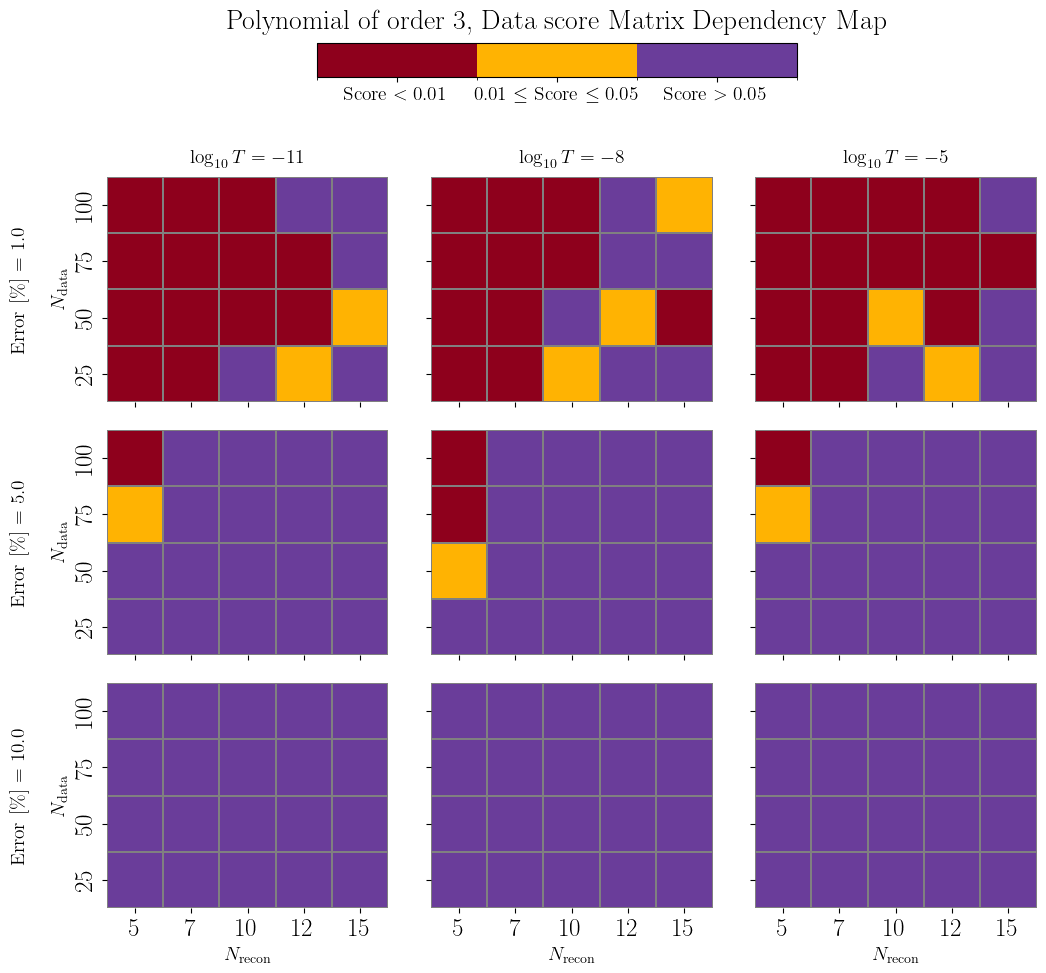

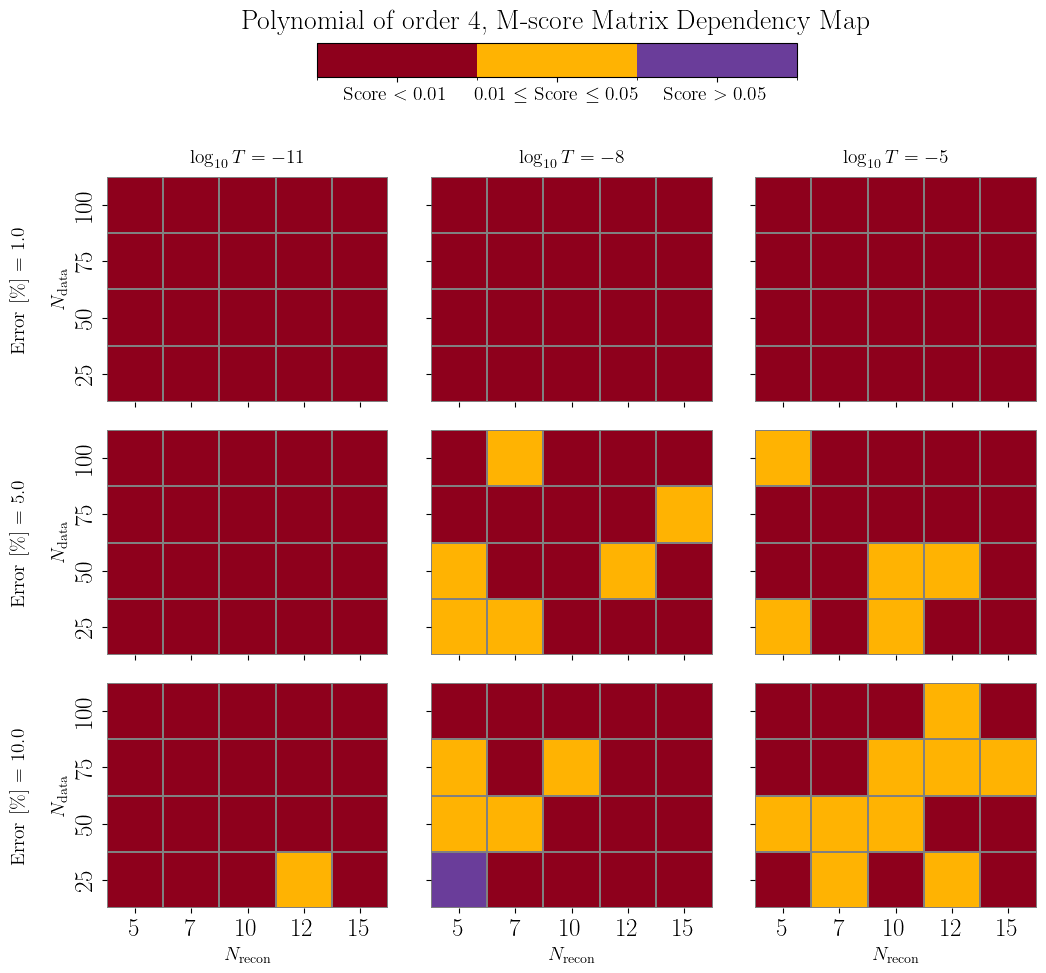

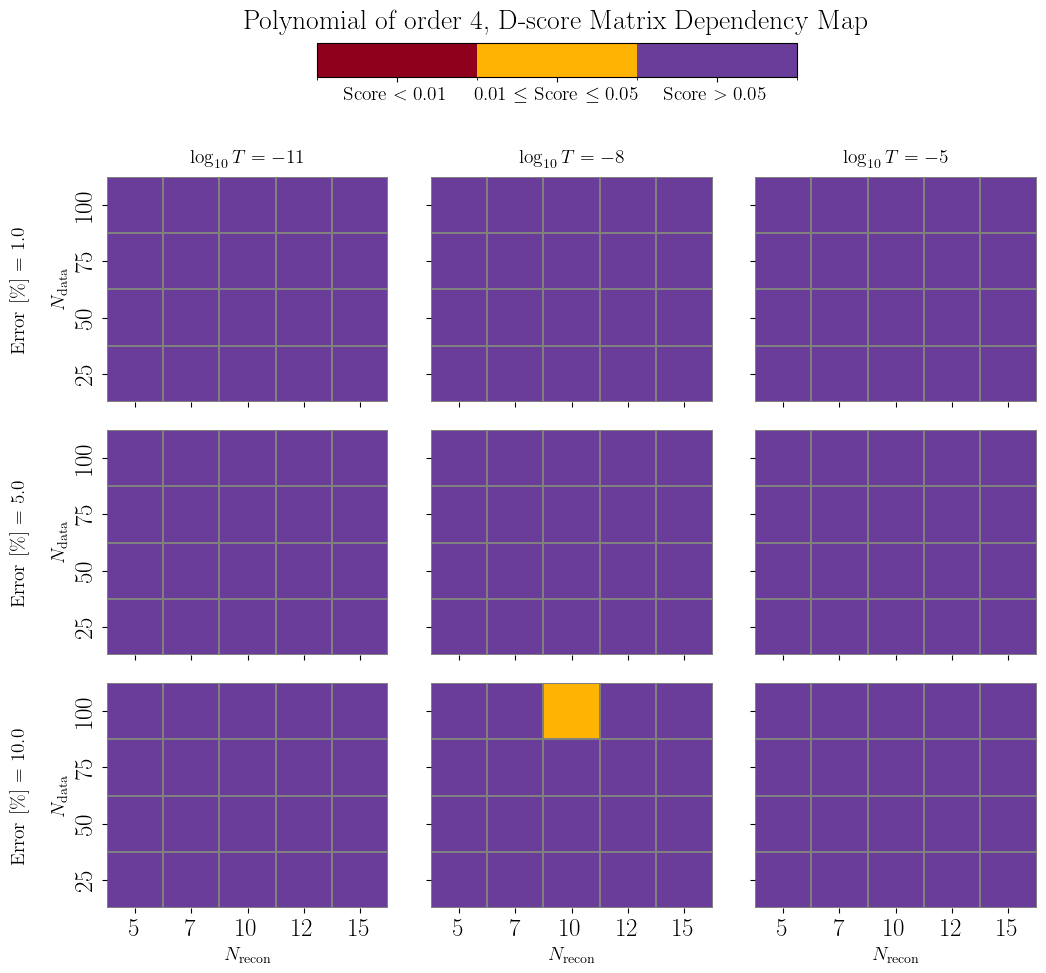

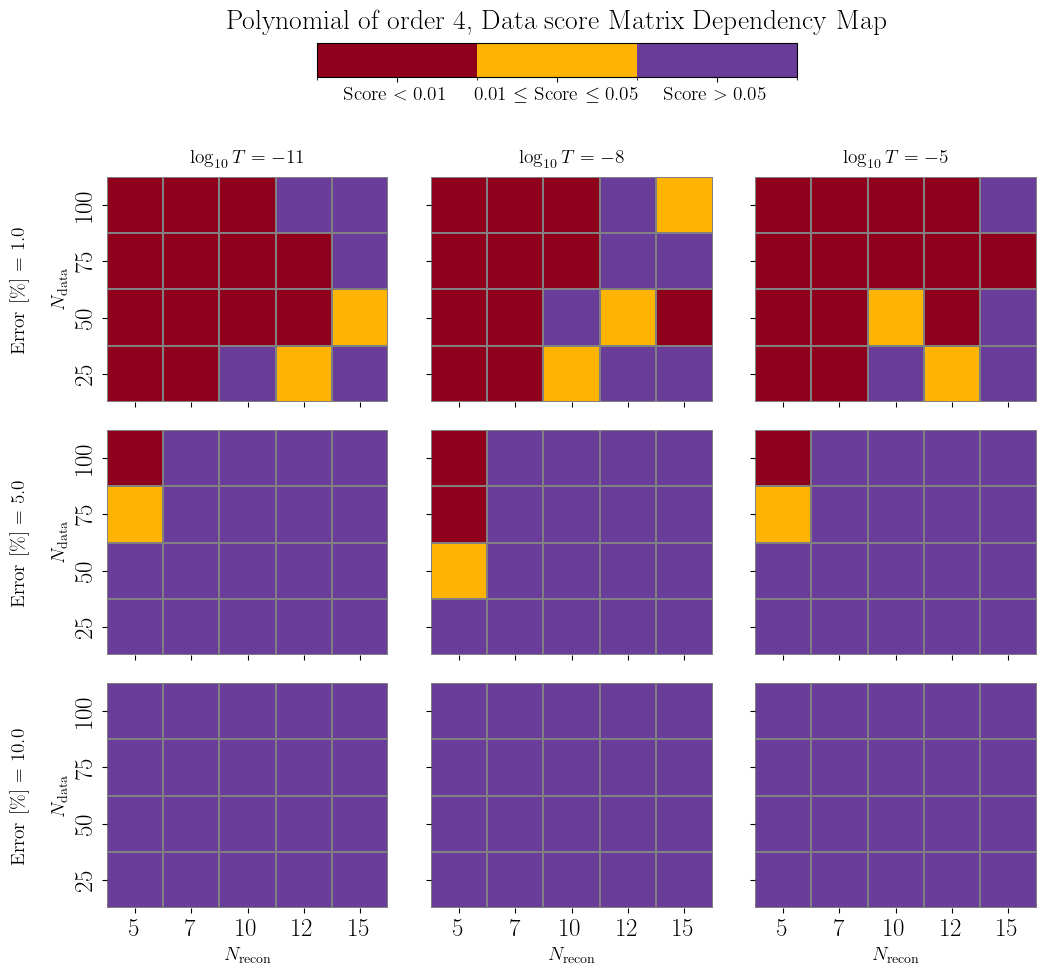

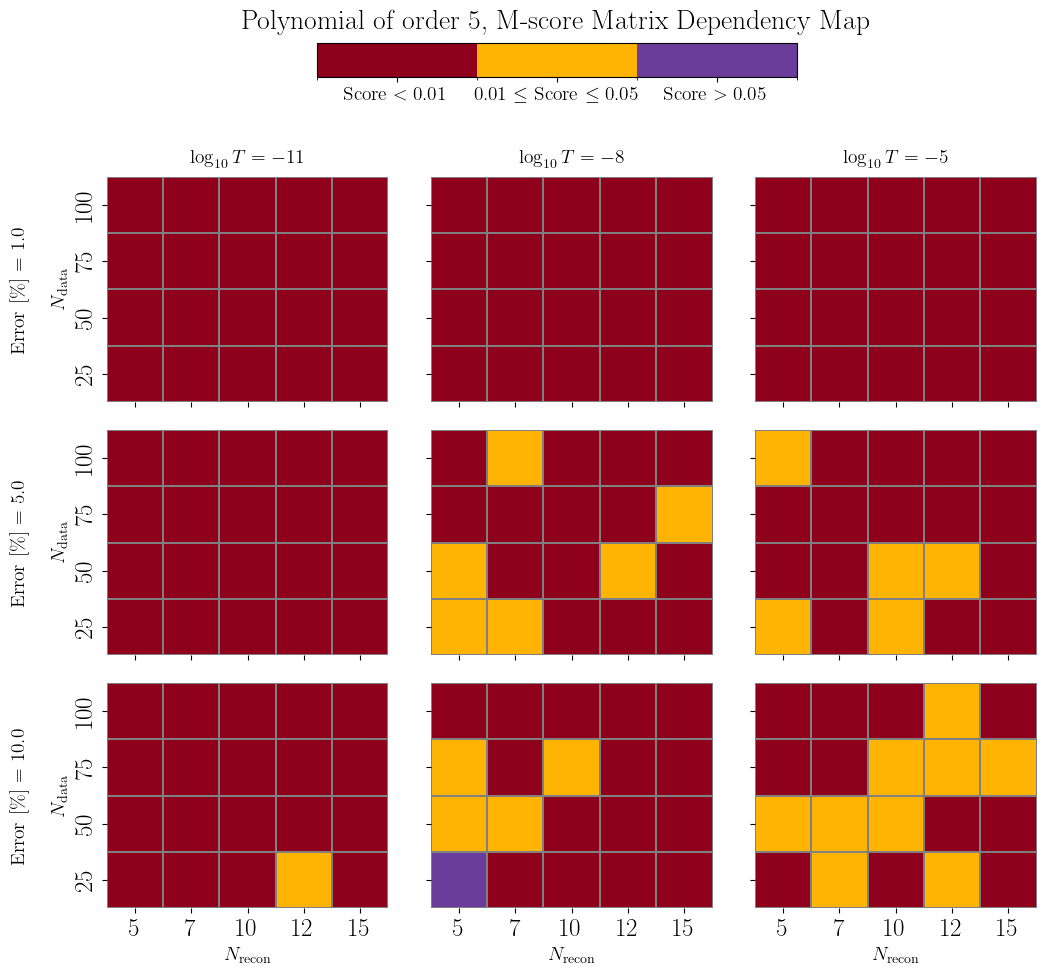

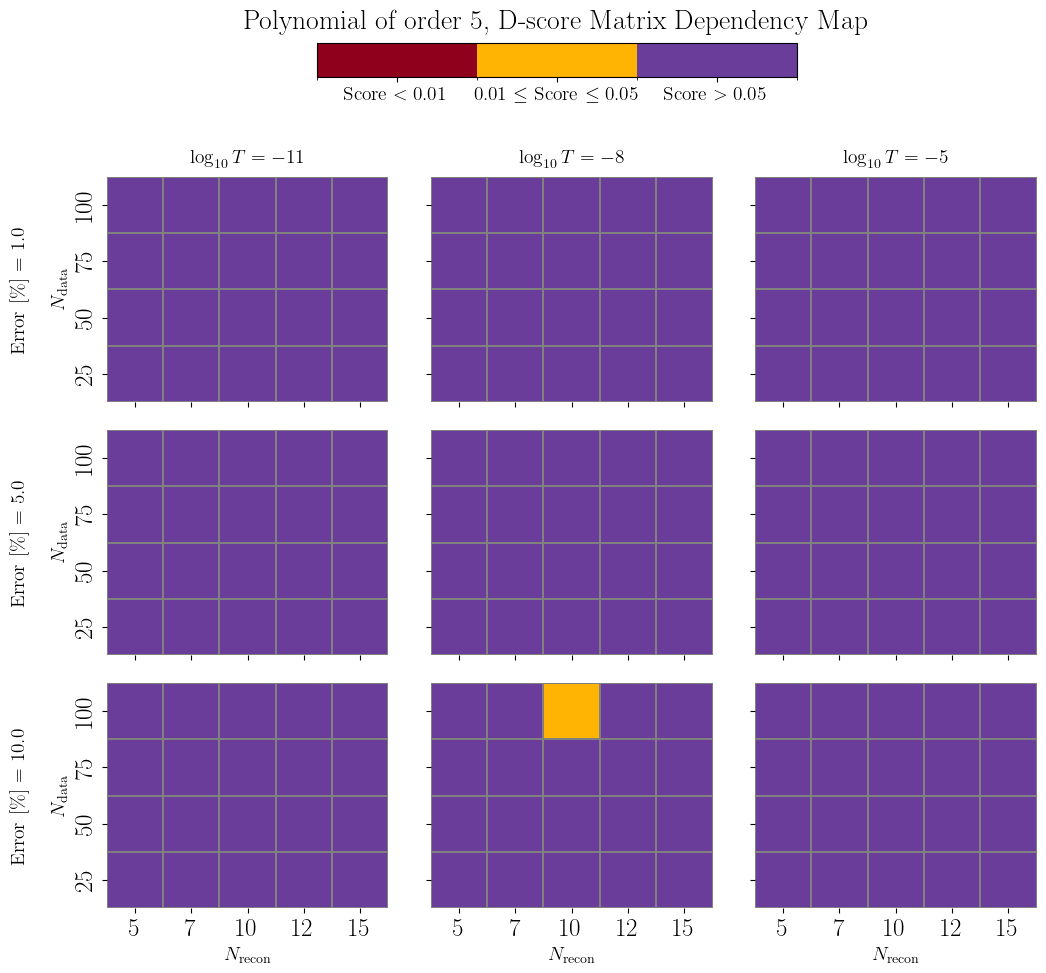

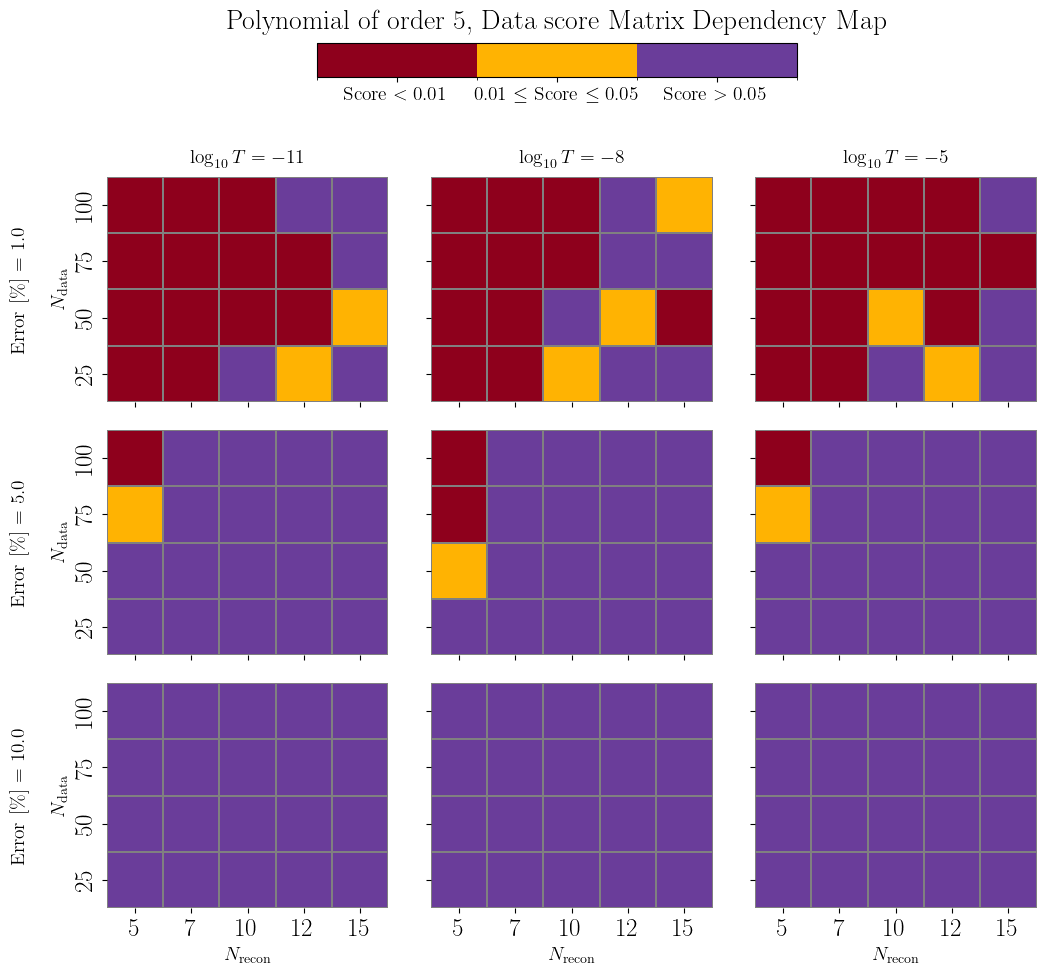

In [95]:
method_df = results[(results['method']=='MAP') & (results['kernel']=='RBF')]
for order in results['order'].unique():
    ord_df = method_df[method_df['order']==3]
    for score_col in ['M-score','D-score','Data score']:
        cols_to_keep = [score_col]+parameters
        df = ord_df.drop(columns=[col for col in ord_df.columns if col not in cols_to_keep])

        my_colors  = [red,yellow,"#6a3d9a"]  # Red, Yellow, Purple
        boundaries = [0.0, 0.01, 0.05, 1.0]
        
        cmap = mcolors.ListedColormap(my_colors)
        norm = mcolors.BoundaryNorm(boundaries, cmap.N)
        # --- 1. Identify unique sorted values for the outer grid parameters ---
        unique_c = sorted(df['error'].unique())
        unique_d = sorted(df['logtruncation'].unique())
        
        nrows = len(unique_c)
        ncols = len(unique_d)

        # --- 2. Initialize the subplot structure ---
        # We allocate an extra narrow column on the far right for a unified colorbar
        fig, axes = plt.subplots(nrows=nrows,ncols=ncols,figsize=(4 * ncols, 4 * nrows+1.5),
                                 sharex="col",sharey="row")

        if nrows == 1 and ncols == 1:
            axes = np.array([[axes]])
        elif nrows == 1:
            axes = axes[np.newaxis, :]
        elif ncols == 1:
            axes = axes[:, np.newaxis]

        # --- 3. Loop through the grid and build the heatmaps ---
        for row_idx, c_val in enumerate(unique_c):
            for col_idx, d_val in enumerate(unique_d):
        
                ax = axes[row_idx, col_idx]
        
                # Filter the dataframe for the specific combination of c and d
                sub_df = df[(df['error'] == c_val) & (df['logtruncation'] == d_val)]
        
                if not sub_df.empty:
                    matrix_df = sub_df.pivot(index='Ndata',columns='Nrecon',values=score_col)
        
                    # Sort index and columns explicitly so axes match across all subplots
                    matrix_df = matrix_df.sort_index(ascending=False).sort_index(axis=1)
        
                    sb.heatmap(matrix_df,ax=ax,cmap=cmap,norm=norm,cbar=False,square=True,linewidths=0.2,linecolor="gray")
                else:
                    # Handle empty combinations gracefully
                    ax.text(0.5,0.5,"No Data",ha="center",va="center",transform=ax.transAxes,)
                    ax.set_facecolor("#f0f0f0")
        
                # --- 4. Handle Subplot Labels ---
                # Add labels designating the outer grid positions (only on edges to prevent clutter)
                if col_idx == 0:
                    ax.set_ylabel(r"Error [\%] = " + f"{c_val}" + "\n\n" + r"$N_{\rm data}$", fontsize=14)
                else:
                    ax.set_ylabel("")  # Hidden by sharey, but clears out automatic labels
        
                if row_idx == 0:
                    ax.set_title(f"$\log_{{10}}{{T}} = {d_val}$", fontsize=14, pad=10)
        
                if row_idx == nrows - 1:
                    ax.set_xlabel(r'$N_{\rm recon}$', fontsize=14)
                else:
                    ax.set_xlabel("")
        
        fig.suptitle(f"Polynomial of order {order}, {score_col} Matrix Dependency Map",fontsize=20,fontweight="bold",y=0.85)
        plt.subplots_adjust(top=0.83, bottom=0.08, hspace=-0.5, wspace=0.15)

        # Create a custom horizontal axis directly below the suptitle
        # Coordinates format: [left_x, bottom_y, width, height] as fractions of the figure
        cbar_ax = fig.add_axes([0.3, 0.8, 0.4, 0.025])
        
        # Create a structural mappable link
        mappable = plt.cm.ScalarMappable(norm=norm, cmap=cmap)
        
        # Build the unified colorbar
        cbar = fig.colorbar(mappable,cax=cbar_ax,orientation="horizontal",spacing="uniform",ticks=[0.005, 0.03, 0.525],)
        
        # Center labels cleanly beneath each discrete colored block
        cbar.ax.set_xticklabels([r"Score $< 0.01$", r"$0.01 \leq$ Score $\leq 0.05$", r"Score $> 0.05$"],
                                fontsize=14,fontweight="bold")
        cbar.ax.xaxis.set_ticks_position("bottom")